In [ ]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["figure.dpi"] = 120

# --- DuckDB setup with memory safety ---
con = duckdb.connect()
con.execute("SET memory_limit = '2GB'")
con.execute("SET threads = 4")

# --- Data paths (local setup) ---
COSTS_PATH       = 'data/costs/costs.parquet'
PRICES_PATH      = 'data/prices/prices.parquet'
SIM_DAILY_PATH   = 'data/sim_daily/sim_daily_*.parquet'
SIM_MONTHLY_PATH = 'data/sim_monthly/sim_monthly_*.parquet'

# Years in dataset
YEARS = [2020, 2021, 2022, 2023]

# --- Register views ---
con.execute(f"CREATE VIEW costs AS SELECT * FROM read_parquet('{COSTS_PATH}')")
con.execute(f"""
    CREATE VIEW prices AS
    SELECT *, STRFTIME(DATETIME, '%Y-%m') AS MONTH
    FROM read_parquet('{PRICES_PATH}')
""")
con.execute(f"""
    CREATE VIEW sim_daily AS
    SELECT *, YEAR(DATETIME) AS YEAR, MONTH(DATETIME) AS MO, DAY(DATETIME) AS DAY
    FROM read_parquet('{SIM_DAILY_PATH}')
""")

SIM_MONTHLY_AVAILABLE = os.path.exists('data/sim_monthly') and \
    len(os.listdir('data/sim_monthly')) > 0
if SIM_MONTHLY_AVAILABLE:
    con.execute(f"""
        CREATE VIEW sim_monthly AS
        SELECT *, YEAR(DATETIME) AS YEAR, MONTH(DATETIME) AS MO
        FROM read_parquet('{SIM_MONTHLY_PATH}')
    """)
    print("View sim_monthly created.")
else:
    SIM_MONTHLY_AVAILABLE = False
    print("sim_monthly NOT available.")

print("Views created: costs, prices, sim_daily" + (", sim_monthly" if SIM_MONTHLY_AVAILABLE else ""))

## Section 1 — Data Inventory

Schema, row counts, and EID counts across datasets.

**Universe strategy — Hybrid (Option C)**

The universe is the union of two EID pools:

| Pool | Source | Rationale |
|------|--------|-----------|
| Market-validated | EIDs in costs OR prices | Known to have traded; PR/C ground truth exists |
| Strong-sim | EIDs with high ACTIVATIONLEVEL AND high \|PSM\| in sim_monthly | May be genuinely new opportunities the simulation predicts |

Both pools are crossed with the sim_monthly (or sim_daily) month/PEAKID grid.
A boolean flag `is_sim_only` marks which rows come exclusively from the
simulation pool — this lets the model and analyst distinguish the two cases.

**Thresholds** are percentile-based and computed from the data, making them
robust across years and avoiding arbitrary magic numbers.

In [2]:
# --- Schema inspection ---
for view_name in ['costs', 'prices', 'sim_daily'] + (['sim_monthly'] if SIM_MONTHLY_AVAILABLE else []):
    print(f"\n{'='*60}")
    print(f"  {view_name.upper()}")
    print(f"{'='*60}")
    schema = con.execute(f"DESCRIBE {view_name}").fetchdf()
    print(schema.to_string(index=False))
    count = con.execute(f"SELECT COUNT(*) AS n FROM {view_name}").fetchone()[0]
    print(f"\nTotal rows: {count:,}")

# EID counts per source
eid_costs     = con.execute("SELECT COUNT(DISTINCT EID) AS n FROM costs").fetchone()[0]
eid_prices    = con.execute("SELECT COUNT(DISTINCT EID) AS n FROM prices").fetchone()[0]
eid_sim_daily = con.execute("SELECT COUNT(DISTINCT EID) AS n FROM sim_daily").fetchone()[0]

print(f"\nDistinct EIDs — costs: {eid_costs}, prices: {eid_prices}, sim_daily: {eid_sim_daily}")
if SIM_MONTHLY_AVAILABLE:
    eid_sim_monthly = con.execute("SELECT COUNT(DISTINCT EID) AS n FROM sim_monthly").fetchone()[0]
    print(f"Distinct EIDs — sim_monthly: {eid_sim_monthly}")


  COSTS
column_name column_type null  key default extra
        EID    SMALLINT  YES None    None  None
      MONTH     VARCHAR  YES None    None  None
     PEAKID     TINYINT  YES None    None  None
          C       FLOAT  YES None    None  None

Total rows: 9,092

  PRICES
  column_name  column_type null  key default extra
          EID     SMALLINT  YES None    None  None
     DATETIME TIMESTAMP_NS  YES None    None  None
       PEAKID      TINYINT  YES None    None  None
PRICEREALIZED        FLOAT  YES None    None  None
        MONTH      VARCHAR  YES None    None  None

Total rows: 453,167

  SIM_DAILY
             column_name  column_type null  key default extra
              SCENARIOID      TINYINT  YES None    None  None
                     EID     SMALLINT  YES None    None  None
                DATETIME TIMESTAMP_NS  YES None    None  None
                  PEAKID      TINYINT  YES None    None  None
         ACTIVATIONLEVEL        FLOAT  YES None    None  None
          

## Section 2 — Universe & Target Construction

**Profit formula (confirmed by MAG)**:
```
PROFIT = |PR| - |C|
TARGET = 1 if PROFIT > 0 else 0
```

**Universe**: Hybrid pool (market-validated EIDs UNION strong-sim EIDs),
crossed with sim_monthly month/PEAKID combinations.

**`is_sim_only` flag**: 1 if the EID has no history in costs or prices
(pure simulation candidate), 0 if market-validated. This flag becomes a
model feature — the model can learn to discount or weight sim-only EIDs.

**`pr_partial_current`**: sum of prices for days 1-7 of month M —
the partial current-month price observable at decision cutoff.

**Threshold constants** (`SIM_ACTIVATION_PCT`, `SIM_PSM_PCT`) control how
aggressively new EIDs are pulled in from simulations. Defaults: 80th
percentile for both — meaning only the top 20% of simulated signals qualify.

In [ ]:
# ═══════════════════════════════════════════════════════════════
# HYBRID UNIVERSE — Option C
# Pool 1: EIDs with any history in costs or prices (market-validated)
# Pool 2: EIDs with strong simulation signal but no market history yet
# Union of both, crossed with sim month/PEAKID grid.
# ═══════════════════════════════════════════════════════════════

# ── Tunable thresholds ──────────────────────────────────────────
SIM_ACTIVATION_PCT = 80   # top 20% of ACTIVATIONLEVEL values
SIM_PSM_PCT        = 80   # top 20% of |PSM|/|PSD| values

# ── Pool 1: market-validated EIDs ───────────────────────────────
market_eids = con.execute("""
    SELECT DISTINCT EID FROM costs
    UNION
    SELECT DISTINCT EID FROM prices
""").fetchdf()
con.register('market_eids', market_eids)
print(f"Pool 1 — market-validated EIDs: {len(market_eids):,}")

# ── Compute percentile thresholds ───────────────────────────────
# Memory-safe: use single year (2023) for threshold estimation.
# Percentile thresholds are stable across years.
if SIM_MONTHLY_AVAILABLE:
    thresholds = con.execute(f"""
        SELECT
            APPROX_QUANTILE(ACTIVATIONLEVEL,  CAST({SIM_ACTIVATION_PCT}/100.0 AS FLOAT)) AS act_thresh,
            APPROX_QUANTILE(ABS(PSM),          CAST({SIM_PSM_PCT}/100.0 AS FLOAT))       AS psm_thresh
        FROM read_parquet('data/sim_monthly/sim_monthly_2023.parquet')
        WHERE ACTIVATIONLEVEL > 0 AND PSM != 0
    """).fetchone()
else:
    thresholds = con.execute(f"""
        SELECT
            APPROX_QUANTILE(ACTIVATIONLEVEL,  CAST({SIM_ACTIVATION_PCT}/100.0 AS FLOAT)) AS act_thresh,
            APPROX_QUANTILE(ABS(PSD),          CAST({SIM_PSM_PCT}/100.0 AS FLOAT))       AS psm_thresh
        FROM read_parquet('data/sim_daily/sim_daily_2023.parquet')
        WHERE ACTIVATIONLEVEL > 0 AND PSD != 0
    """).fetchone()

ACT_THRESH, PSM_THRESH = thresholds[0], thresholds[1]
print(f"Thresholds (p{SIM_ACTIVATION_PCT}): ACTIVATIONLEVEL >= {ACT_THRESH:.4f}")
print(f"Thresholds (p{SIM_PSM_PCT}):  |PSM|/|PSD|    >= {PSM_THRESH:.4f}")

# ── Pool 2: strong-sim EIDs not already in market ────────────────
# Year-by-year iteration for memory safety at 2GB limit.
strong_sim_eids_list = []
for year in YEARS:
    if SIM_MONTHLY_AVAILABLE:
        df_year = con.execute(f"""
            SELECT DISTINCT EID
            FROM read_parquet('data/sim_monthly/sim_monthly_{year}.parquet')
            WHERE ACTIVATIONLEVEL >= {ACT_THRESH}
              AND ABS(PSM)         >= {PSM_THRESH}
              AND EID NOT IN (SELECT EID FROM market_eids)
        """).fetchdf()
    else:
        df_year = con.execute(f"""
            SELECT DISTINCT EID
            FROM read_parquet('data/sim_daily/sim_daily_{year}.parquet')
            WHERE DAY(DATETIME) BETWEEN 1 AND 7
              AND ACTIVATIONLEVEL >= {ACT_THRESH}
              AND ABS(PSD)         >= {PSM_THRESH}
              AND EID NOT IN (SELECT EID FROM market_eids)
        """).fetchdf()
    strong_sim_eids_list.append(df_year)
    print(f"  Year {year}: {len(df_year):,} strong-sim EIDs found")

strong_sim_eids = pd.concat(strong_sim_eids_list, ignore_index=True).drop_duplicates()
con.register('strong_sim_eids', strong_sim_eids)
print(f"Pool 2 — strong-sim-only EIDs:  {len(strong_sim_eids):,}")

# ── Union both pools → candidate EIDs ────────────────────────────
candidate_eids = con.execute("""
    SELECT EID, 0 AS is_sim_only FROM market_eids
    UNION ALL
    SELECT EID, 1 AS is_sim_only FROM strong_sim_eids
""").fetchdf()
con.register('candidate_eids', candidate_eids)
total_eids = len(candidate_eids)
sim_only_count = candidate_eids['is_sim_only'].sum()
print(f"\nTotal candidate EIDs:  {total_eids:,}")
print(f"  Market-validated:    {total_eids - sim_only_count:,} ({(1-sim_only_count/total_eids)*100:.1f}%)")
print(f"  Sim-only:            {sim_only_count:,} ({sim_only_count/total_eids*100:.1f}%)")

# ── Cross with sim month/PEAKID grid (year-by-year for memory) ──
universe_parts = []
source = 'sim_monthly' if SIM_MONTHLY_AVAILABLE else 'sim_daily'
print(f'\nBuilding universe from {source} x candidate EIDs (year-by-year)...')
for year in YEARS:
    if SIM_MONTHLY_AVAILABLE:
        path = f"data/sim_monthly/sim_monthly_{year}.parquet"
    else:
        path = f"data/sim_daily/sim_daily_{year}.parquet"
    df_year = con.execute(f"""
        SELECT DISTINCT
            s.EID,
            STRFTIME(s.DATETIME, '%Y-%m') AS MONTH,
            s.PEAKID,
            c.is_sim_only
        FROM read_parquet('{path}') s
        INNER JOIN candidate_eids c ON s.EID = c.EID
        WHERE YEAR(s.DATETIME) = {year}
    """).fetchdf()
    universe_parts.append(df_year)
    print(f"  {year}: {len(df_year):,} rows")

universe_df = pd.concat(universe_parts, ignore_index=True).drop_duplicates(
    subset=['EID', 'MONTH', 'PEAKID']).sort_values(['MONTH', 'EID', 'PEAKID']).reset_index(drop=True)

print(f"\nUniverse shape: {universe_df.shape}")
print(f"Unique EIDs:    {universe_df['EID'].nunique():,}")
print(f"Sim-only rows:  {universe_df['is_sim_only'].sum():,} ({universe_df['is_sim_only'].mean()*100:.1f}%)")
print(f"Month range:    {universe_df['MONTH'].min()} to {universe_df['MONTH'].max()}")
universe_df.head()

In [ ]:
# --- Build target: PR and C per (EID, MONTH, PEAKID) ---
# is_sim_only travels through the join so it's available in master_df
con.register('universe', universe_df)

# Full monthly PR — used to define TARGET (ground truth label).
# PR_signed kept for directional analysis (sign = energy flow direction).
monthly_pr = con.execute("""
    SELECT EID, MONTH, PEAKID,
           ABS(SUM(PRICEREALIZED)) AS PR,
           SUM(PRICEREALIZED)      AS PR_signed
    FROM prices
    GROUP BY EID, MONTH, PEAKID
""").fetchdf()
con.register('monthly_pr', monthly_pr)

# Partial-month price: days 1-7 of DECISION_MONTH M (= TARGET_MONTH - 1) — cutoff-safe current signal.
partial_pr = con.execute("""
    SELECT EID,
           MONTH,
           PEAKID,
           ABS(SUM(PRICEREALIZED)) AS pr_partial_current
    FROM prices
    WHERE DAY(DATETIME) BETWEEN 1 AND 7
    GROUP BY EID, MONTH, PEAKID
""").fetchdf()
con.register('partial_pr', partial_pr)

target_df = con.execute("""
    SELECT
        u.EID,
        u.MONTH,
        u.PEAKID,
        u.is_sim_only,
        COALESCE(pr.PR,   0.0)           AS PR,
        COALESCE(pr.PR_signed, 0.0)      AS PR_signed,
        ABS(COALESCE(c.C, 0.0))          AS C,
        COALESCE(pr.PR, 0.0)
            - ABS(COALESCE(c.C, 0.0))    AS PROFIT,
        CASE WHEN COALESCE(pr.PR, 0.0)
                  - ABS(COALESCE(c.C, 0.0)) > 0
             THEN 1 ELSE 0 END           AS TARGET,
        COALESCE(pp.pr_partial_current, 0.0) AS pr_partial_current
    FROM universe u
    LEFT JOIN monthly_pr pr ON u.EID = pr.EID AND u.MONTH = pr.MONTH AND u.PEAKID = pr.PEAKID
    LEFT JOIN costs c        ON u.EID = c.EID  AND u.MONTH = c.MONTH  AND u.PEAKID = c.PEAKID
    LEFT JOIN partial_pr pp  ON u.EID = pp.EID
                             AND pp.MONTH = STRFTIME(STRPTIME(u.MONTH, '%Y-%m') - INTERVAL 1 MONTH, '%Y-%m')
                             AND u.PEAKID = pp.PEAKID
    ORDER BY u.MONTH, u.EID, u.PEAKID
""").fetchdf()

print(f"Target table shape:  {target_df.shape}")
print(f"Unique EIDs:         {target_df['EID'].nunique():,}")
print(f"\nTarget distribution:")
print(target_df['TARGET'].value_counts())
print(f"\nProfitability rate — all:       {target_df['TARGET'].mean()*100:.2f}%")
mkt = target_df[target_df['is_sim_only'] == 0]
sim = target_df[target_df['is_sim_only'] == 1]
print(f"Profitability rate — market:    {mkt['TARGET'].mean()*100:.2f}% ({len(mkt):,} rows)")
if len(sim) > 0:
    print(f"Profitability rate — sim-only:  {sim['TARGET'].mean()*100:.2f}% ({len(sim):,} rows)")
print(f"\nRows C=0:  {(target_df['C'] == 0).sum():,}")
print(f"Rows PR=0: {(target_df['PR'] == 0).sum():,}")
target_df.head(10)

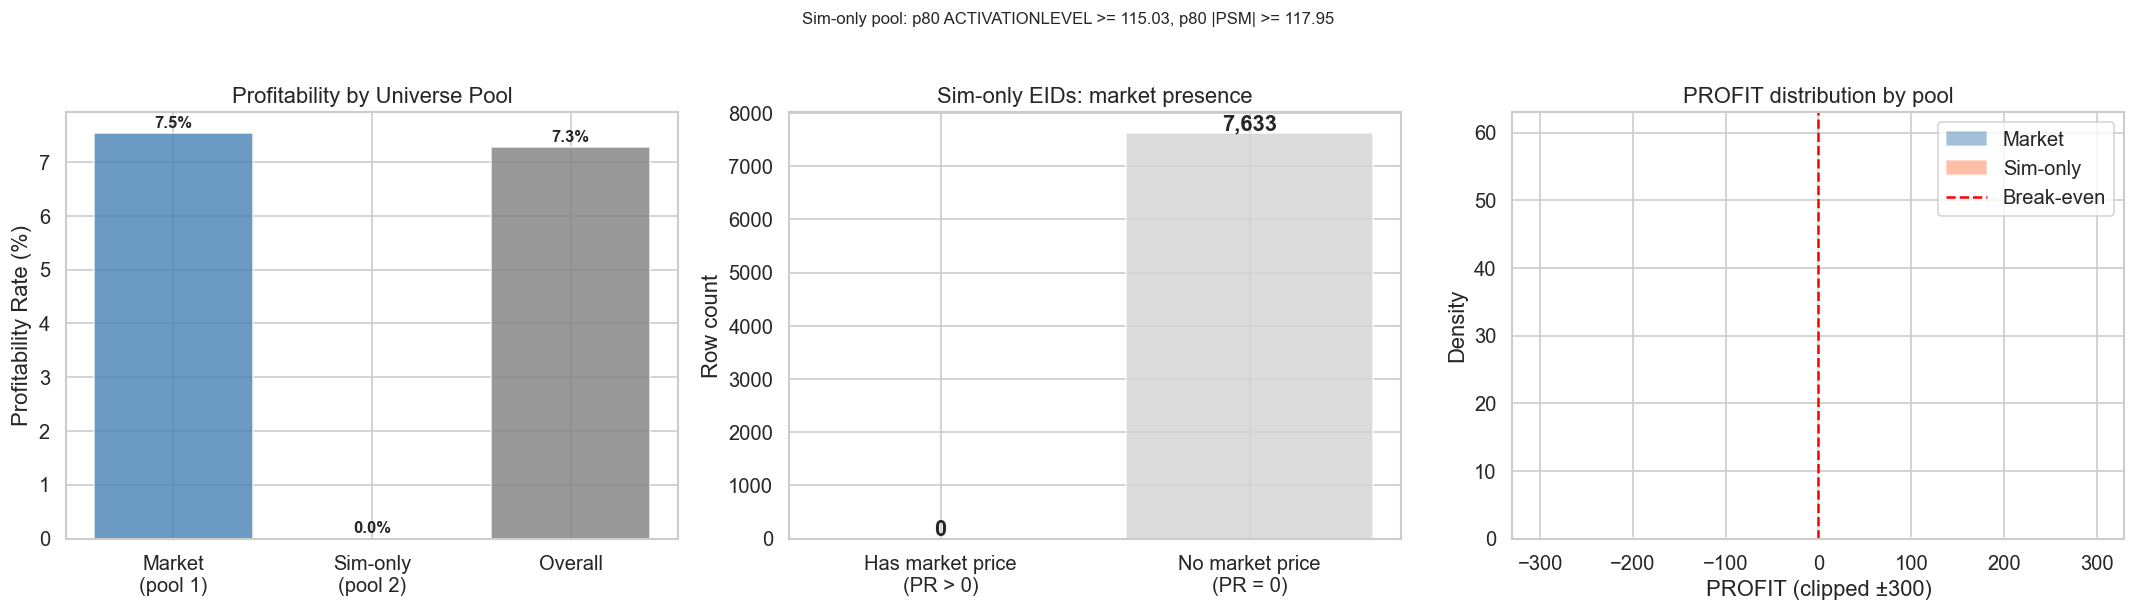


If sim-only profitability rate is near 0% and PR=0 dominates,
consider raising SIM_ACTIVATION_PCT / SIM_PSM_PCT thresholds.
If sim-only rate is comparable to market, the pool is adding genuine signal.


In [7]:
# --- Sim-only EID quality check ---
# Validate that the sim-only pool is adding genuine signal, not noise.
# Key questions:
#   1. What profitability rate do sim-only EIDs achieve? (should be > base rate)
#   2. How many sim-only EIDs actually appear in prices/costs in the same month?
#      (non-zero PR or C means the market DID trade them — good validation)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Profitability rate: market vs sim-only
rates = {
    'Market\n(pool 1)': target_df[target_df['is_sim_only']==0]['TARGET'].mean()*100,
    'Sim-only\n(pool 2)': target_df[target_df['is_sim_only']==1]['TARGET'].mean()*100,
    'Overall': target_df['TARGET'].mean()*100,
}
colors = ['steelblue', 'coral', 'gray']
bars = axes[0].bar(rates.keys(), rates.values(), color=colors, alpha=0.8)
for bar, val in zip(bars, rates.values()):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 0.1,
                 f'{val:.1f}%', ha='center', fontweight='bold', fontsize=10)
axes[0].set_ylabel('Profitability Rate (%)')
axes[0].set_title('Profitability by Universe Pool')

# 2. Sim-only EIDs: did the market ever trade them? (PR > 0)
sim_rows = target_df[target_df['is_sim_only'] == 1]
sim_with_price = (sim_rows['PR'] > 0).sum()
sim_no_price   = (sim_rows['PR'] == 0).sum()
axes[1].bar(['Has market price\n(PR > 0)', 'No market price\n(PR = 0)'],
            [sim_with_price, sim_no_price], color=['steelblue', 'lightgray'], alpha=0.8)
axes[1].set_ylabel('Row count')
axes[1].set_title('Sim-only EIDs: market presence')
axes[1].text(0, sim_with_price + 50, f'{sim_with_price:,}', ha='center', fontweight='bold')
axes[1].text(1, sim_no_price  + 50, f'{sim_no_price:,}',  ha='center', fontweight='bold')

# 3. PROFIT distribution: market vs sim-only (clipped)
for label, mask, color in [
    ('Market', target_df['is_sim_only']==0, 'steelblue'),
    ('Sim-only', target_df['is_sim_only']==1, 'coral'),
]:
    subset = target_df[mask]['PROFIT'].clip(-300, 300)
    axes[2].hist(subset, bins=60, alpha=0.5, color=color, label=label, density=True)
axes[2].axvline(0, color='red', linestyle='--', label='Break-even')
axes[2].set_xlabel('PROFIT (clipped ±300)')
axes[2].set_ylabel('Density')
axes[2].set_title('PROFIT distribution by pool')
axes[2].legend()

plt.suptitle(
    f'Sim-only pool: p{SIM_ACTIVATION_PCT} ACTIVATIONLEVEL >= {ACT_THRESH:.2f}, '
    f'p{SIM_PSM_PCT} |PSM| >= {PSM_THRESH:.2f}',
    fontsize=10, y=1.02
)
plt.tight_layout()
plt.show()

print("\nIf sim-only profitability rate is near 0% and PR=0 dominates,")
print("consider raising SIM_ACTIVATION_PCT / SIM_PSM_PCT thresholds.")
print("If sim-only rate is comparable to market, the pool is adding genuine signal.")

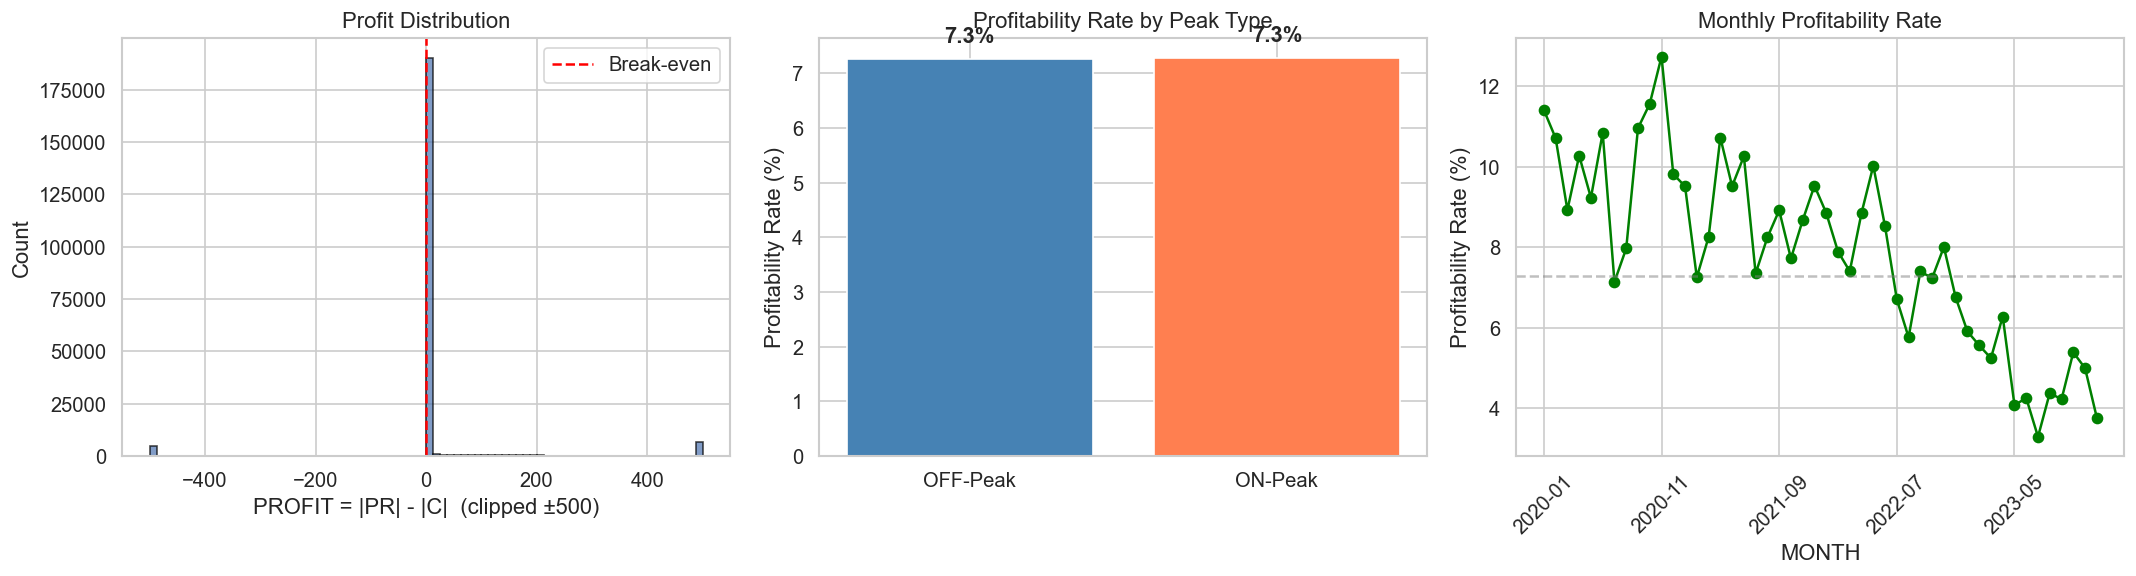

In [8]:
# --- PROFIT distribution visualization ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# PROFIT histogram (clipped for readability)
profit_clipped = target_df['PROFIT'].clip(-500, 500)
axes[0].hist(profit_clipped, bins=80, edgecolor='black', alpha=0.7)
axes[0].axvline(0, color='red', linestyle='--', label='Break-even')
axes[0].set_xlabel('PROFIT = |PR| - |C|  (clipped ±500)')
axes[0].set_ylabel('Count')
axes[0].set_title('Profit Distribution')
axes[0].legend()

# By PEAKID
for pid, label in [(0, 'OFF-Peak'), (1, 'ON-Peak')]:
    subset = target_df[target_df['PEAKID'] == pid]
    rate = subset['TARGET'].mean() * 100
    axes[1].bar(label, rate, color='steelblue' if pid == 0 else 'coral')
    axes[1].text(label, rate + 0.3, f'{rate:.1f}%', ha='center', fontweight='bold')

axes[1].set_ylabel('Profitability Rate (%)')
axes[1].set_title('Profitability Rate by Peak Type')

# Monthly profitability rate
monthly_rate = target_df.groupby('MONTH')['TARGET'].mean() * 100
monthly_rate.plot(ax=axes[2], marker='o', color='green')
axes[2].axhline(y=target_df['TARGET'].mean()*100, color='gray', linestyle='--', alpha=0.5)
axes[2].set_ylabel('Profitability Rate (%)')
axes[2].set_title('Monthly Profitability Rate')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## Section 3 — Anti-Leakage Time Alignment

Decision is made on the **7th of month M** for **target month M+1**.

| Data Source | Available Window | Usage |
|-------------|-----------------|-------|
| sim_daily   | Days **1–7** of month **M** | Decision-time features |
| sim_monthly | All hours of month **M+1** | Forward simulation features (allowed) |
| prices (hist) | Up to day 7 of month **M** | Historical features for M-1, M-2... |
| costs (hist)  | Month **M** and earlier | Historical cost features |

We add a `DECISION_MONTH` column = TARGET_MONTH minus 1 month.

In [9]:
# --- Add DECISION_MONTH ---
target_df['DECISION_MONTH'] = (
    pd.to_datetime(target_df['MONTH'] + '-01') - pd.DateOffset(months=1)
).dt.strftime('%Y-%m')

print(f"TARGET_MONTH range:   {target_df['MONTH'].min()} → {target_df['MONTH'].max()}")
print(f"DECISION_MONTH range: {target_df['DECISION_MONTH'].min()} → {target_df['DECISION_MONTH'].max()}")
print("\nSample alignment:")
target_df[['EID', 'MONTH', 'DECISION_MONTH', 'PEAKID', 'PR', 'C', 'PROFIT', 'TARGET']].head(6)

TARGET_MONTH range:   2020-01 → 2023-12
DECISION_MONTH range: 2019-12 → 2023-11

Sample alignment:


,EID,MONTH,DECISION_MONTH,PEAKID,PR,C,PROFIT,TARGET
0,2,2020-01,2019-12,0,0.0,0.0,0.0,0
1,2,2020-01,2019-12,1,0.0,0.0,0.0,0
2,3,2020-01,2019-12,0,0.0,0.0,0.0,0
3,3,2020-01,2019-12,1,0.0,0.0,0.0,0
4,10,2020-01,2019-12,0,0.0,0.0,0.0,0
5,10,2020-01,2019-12,1,0.0,0.0,0.0,0


## Section 4 — Feature Engineering from sim_daily

Extract features from **days 1–7 of DECISION_MONTH M** per `(EID, PEAKID)`.

**Anti-leakage filter**: `DAY(DATETIME) BETWEEN 1 AND 7` strictly limits to data available at cutoff.
This is the critical fix — without it the model would see days 8–31 of month M, which are future data
at decision time and cause train/test mismatch.

In [ ]:
# --- sim_daily feature extraction (year-by-year, days 1-7 only) ---
# ANTI-LEAKAGE: DAY(DATETIME) BETWEEN 1 AND 7 is MANDATORY
SIM_DAILY_FEATURE_QUERY = """
    SELECT EID,
           STRFTIME(DATETIME, '%Y-%m') AS DECISION_MONTH,
           PEAKID,
           -- Congestion signal (PSD)
           SUM(CASE WHEN PSD != 0 THEN 1 ELSE 0 END)          AS psd_nonzero_count,
           AVG(CASE WHEN PSD != 0 THEN ABS(PSD) END)          AS psd_abs_nonzero_mean,
           STDDEV(CASE WHEN PSD != 0 THEN ABS(PSD) END)       AS psd_abs_nonzero_std,
           SUM(ABS(PSD))                                       AS psd_abs_sum,
           AVG(CASE WHEN PSD != 0 THEN PSD END)               AS psd_signed_mean,
           MAX(ABS(PSD))                                       AS psd_abs_max,
           -- Activation level
           AVG(ACTIVATIONLEVEL)                                AS activation_mean,
           MAX(ACTIVATIONLEVEL)                                AS activation_max,
           SUM(CASE WHEN ACTIVATIONLEVEL > 0 THEN 1 ELSE 0 END) AS activation_nonzero_count,
           -- Source-based impacts: abs_mean for all
           AVG(ABS(WINDIMPACT))                                AS wind_abs_mean,
           AVG(ABS(SOLARIMPACT))                               AS solar_abs_mean,
           AVG(ABS(HYDROIMPACT))                               AS hydro_abs_mean,
           AVG(ABS(NONRENEWBALIMPACT))                         AS nonrenew_abs_mean,
           AVG(ABS(EXTERNALIMPACT))                            AS external_abs_mean,
           -- Explanatory variables: abs_mean
           AVG(ABS(LOADIMPACT))                                AS load_abs_mean,
           AVG(ABS(TRANSMISSIONOUTAGEIMPACT))                  AS transoutage_abs_mean,
           -- ENRICHED impacts: log_abs_mean + abs_max for HYDRO, WIND, LOAD
           -- log_abs_mean: robust to extreme outliers (HYDRO: [-1M, +111K] while p99 ~17)
           AVG(LN(1 + ABS(HYDROIMPACT)))                      AS hydro_log_abs_mean,
           MAX(ABS(HYDROIMPACT))                               AS hydro_abs_max,
           AVG(LN(1 + ABS(WINDIMPACT)))                       AS wind_log_abs_mean,
           MAX(ABS(WINDIMPACT))                                AS wind_abs_max,
           AVG(LN(1 + ABS(LOADIMPACT)))                       AS load_log_abs_mean,
           MAX(ABS(LOADIMPACT))                                AS load_abs_max,
           -- Scenario-specific PSD (S1 vs S2/S3 — r=0.22 vs r=0.87)
           AVG(CASE WHEN SCENARIOID = 1    THEN ABS(PSD) END) AS psd_abs_s1_mean,
           AVG(CASE WHEN SCENARIOID IN (2,3) THEN ABS(PSD) END) AS psd_abs_s23_mean,
           -- Inter-scenario spread (uncertainty)
           STDDEV(CASE WHEN PSD != 0 THEN PSD END)            AS psd_scenario_spread,
           -- Trend: early (days 1-3) vs late (days 4-7) — momentum signal
           AVG(CASE WHEN DAY(DATETIME) <= 3            THEN ABS(PSD) END) AS psd_abs_early,
           AVG(CASE WHEN DAY(DATETIME) BETWEEN 4 AND 7 THEN ABS(PSD) END) AS psd_abs_late
    FROM read_parquet('data/sim_daily/sim_daily_{year}.parquet')
    WHERE DAY(DATETIME) BETWEEN 1 AND 7 AND YEAR(DATETIME) = {year}
    GROUP BY EID, DECISION_MONTH, PEAKID
"""

sim_daily_features_list = []
for year in YEARS:
    print(f"Processing sim_daily {year}...", end=" ")
    query = SIM_DAILY_FEATURE_QUERY.replace('{year}', str(year))
    df_year = con.execute(query).fetchdf()
    sim_daily_features_list.append(df_year)
    print(f"{len(df_year):,} rows")

sim_daily_features = pd.concat(sim_daily_features_list, ignore_index=True)
print(f"\nTotal sim_daily features: {sim_daily_features.shape}")
print(f"Unique EIDs: {sim_daily_features['EID'].nunique()}")
print(f"\nNew enriched columns sample:")
print(sim_daily_features[['hydro_log_abs_mean', 'hydro_abs_max', 
                           'wind_log_abs_mean', 'wind_abs_max',
                           'load_log_abs_mean', 'load_abs_max']].describe().round(4))
sim_daily_features.head()

## Section 5 — Feature Engineering from sim_monthly

Extract features from **TARGET_MONTH M+1** using PSM.

These simulations are produced before the 7th of month M and are therefore **allowed** at decision time.
No day filter needed here — the entire target month simulation is available.

In [ ]:
# --- sim_monthly feature extraction ---
if SIM_MONTHLY_AVAILABLE:
    SIM_MONTHLY_FEATURE_QUERY = """
        SELECT EID,
               STRFTIME(DATETIME, '%Y-%m') AS TARGET_MONTH,
               PEAKID,
               SUM(CASE WHEN PSM != 0 THEN 1 ELSE 0 END)           AS psm_nonzero_count,
               AVG(CASE WHEN PSM != 0 THEN ABS(PSM) END)           AS psm_abs_nonzero_mean,
               STDDEV(CASE WHEN PSM != 0 THEN ABS(PSM) END)        AS psm_abs_nonzero_std,
               SUM(ABS(PSM))                                        AS psm_abs_sum,
               AVG(CASE WHEN PSM != 0 THEN PSM END)                AS psm_signed_mean,
               MAX(ABS(PSM))                                        AS psm_abs_max,
               AVG(ACTIVATIONLEVEL)                                 AS psm_activation_mean,
               MAX(ACTIVATIONLEVEL)                                 AS psm_activation_max,
               AVG(ABS(WINDIMPACT))                                 AS psm_wind_abs_mean,
               AVG(ABS(SOLARIMPACT))                                AS psm_solar_abs_mean,
               AVG(ABS(HYDROIMPACT))                                AS psm_hydro_abs_mean,
               AVG(ABS(NONRENEWBALIMPACT))                          AS psm_nonrenew_abs_mean,
               AVG(ABS(EXTERNALIMPACT))                             AS psm_external_abs_mean,
               AVG(CASE WHEN SCENARIOID = 1     THEN ABS(PSM) END) AS psm_abs_s1_mean,
               AVG(CASE WHEN SCENARIOID IN (2,3) THEN ABS(PSM) END) AS psm_abs_s23_mean,
               STDDEV(CASE WHEN PSM != 0 THEN PSM END)             AS psm_scenario_spread
        FROM read_parquet('data/sim_monthly/sim_monthly_{year}.parquet')
        WHERE YEAR(DATETIME) = {year}
        GROUP BY EID, TARGET_MONTH, PEAKID
    """

    sim_monthly_features_list = []
    for year in YEARS:
        print(f"Processing sim_monthly {year}...", end=" ")
        query = SIM_MONTHLY_FEATURE_QUERY.replace('{year}', str(year))
        df_year = con.execute(query).fetchdf()
        sim_monthly_features_list.append(df_year)
        print(f"{len(df_year):,} rows")

    sim_monthly_features = pd.concat(sim_monthly_features_list, ignore_index=True)
    print(f"\nTotal sim_monthly features: {sim_monthly_features.shape}")
else:
    sim_monthly_features = None
    print("[SKIP] sim_monthly not available — PSM features will be absent from master dataset.")

## Section 6 — Historical Lag Features from Prices & Costs

For each opportunity `(EID, TARGET_MONTH=M+1, PEAKID)` we compute lag features
using **fully-observable** historical data only.

**FIX — Issue 2 (leakage)**: `pr_lag1 = shift(1)` gave TARGET_MONTH M+1 the
**full price of month M**, which is unavailable at the decision cutoff (day 7).
All PR/PROFIT lags are now shifted by +1 extra so the nearest full monthly price
is M-1 (two months before the target). `c_lag1` stays at shift(1) because the
case spec explicitly states cost of month M is available at cutoff.

| Feature           | Old shift | New shift | Month used | Cutoff-safe? |
|-------------------|-----------|-----------|------------|--------------|
| pr_lag1           | 1         | **2**     | M-1        | Yes |
| pr_lag2           | 2         | **3**     | M-2        | Yes |
| pr_lag3           | 3         | **4**     | M-3        | Yes |
| profit_lag1       | 1         | **2**     | M-1        | Yes |
| profit_lag2       | 2         | **3**     | M-2        | Yes |
| target_lag1       | 1         | **2**     | M-1        | Yes |
| c_lag1            | 1         | **1**     | M          | Yes (cost spec) |
| pr_partial_current| n/a       | n/a       | M (day 1-7)| Yes (new) |

**FIX — Issue 4 (NaN conflation)**: `has_history` flags are created BEFORE
any `fillna(0)`, so the model can distinguish a new EID (no history) from an
established EID that happened to have zero profit last period.

In [12]:
# --- FIX: Historical lag features (leakage-corrected + has_history flags) ---
target_sorted = target_df.sort_values(['EID', 'PEAKID', 'MONTH']).copy()
grouped = target_sorted.groupby(['EID', 'PEAKID'])

# FIX (Issue 4): create has_history flags BEFORE any fillna.
# Reflects whether an EID has at least one prior full month of data.
target_sorted['has_pr_history']     = grouped['PR'].shift(2).notna().astype(int)
target_sorted['has_profit_history'] = grouped['PROFIT'].shift(2).notna().astype(int)
target_sorted['has_cost_history']   = grouped['C'].shift(1).notna().astype(int)

# FIX (Issue 2): PR / PROFIT lags shifted by 2+ so nearest full month is M-1.
# c_lag1 stays shift(1): cost of month M is available at cutoff (per case spec).
target_sorted['pr_lag1']     = grouped['PR'].shift(2)       # M-1 full price
target_sorted['pr_lag2']     = grouped['PR'].shift(3)       # M-2 full price
target_sorted['pr_lag3']     = grouped['PR'].shift(4)       # M-3 full price
target_sorted['c_lag1']      = grouped['C'].shift(1)        # M cost (allowed)
target_sorted['profit_lag1'] = grouped['PROFIT'].shift(2)   # M-1 profit
target_sorted['profit_lag2'] = grouped['PROFIT'].shift(3)   # M-2 profit
target_sorted['target_lag1'] = grouped['TARGET'].shift(2)   # M-1 label

# Rolling windows: shift(2) so window covers M-1, M-2, M-3 only
target_sorted['pr_rolling3_mean'] = grouped['PR'].transform(
    lambda x: x.shift(2).rolling(3, min_periods=1).mean())
target_sorted['profit_rolling3_mean'] = grouped['PROFIT'].transform(
    lambda x: x.shift(2).rolling(3, min_periods=1).mean())
target_sorted['profitable_count_3m'] = grouped['TARGET'].transform(
    lambda x: x.shift(2).rolling(3, min_periods=1).sum())

hist_feature_cols = [
    'has_pr_history', 'has_profit_history', 'has_cost_history',
    'pr_lag1', 'pr_lag2', 'pr_lag3', 'c_lag1',
    'profit_lag1', 'profit_lag2', 'target_lag1',
    'pr_rolling3_mean', 'profit_rolling3_mean', 'profitable_count_3m',
]

print('Historical features — non-null rate:')
for col in hist_feature_cols:
    pct = target_sorted[col].notna().mean() * 100
    print(f'  {col}: {pct:.1f}% non-null')

target_with_hist = target_sorted.copy()

Historical features — non-null rate:
  has_pr_history: 100.0% non-null
  has_profit_history: 100.0% non-null
  has_cost_history: 100.0% non-null
  pr_lag1: 94.0% non-null
  pr_lag2: 91.0% non-null
  pr_lag3: 88.0% non-null
  c_lag1: 97.0% non-null
  profit_lag1: 94.0% non-null
  profit_lag2: 91.0% non-null
  target_lag1: 94.0% non-null
  pr_rolling3_mean: 94.0% non-null
  profit_rolling3_mean: 94.0% non-null
  profitable_count_3m: 94.0% non-null


## Section 7 — Master Merge

Join all feature tables with proper time-shift alignment:
- `target_with_hist` `(EID, MONTH=M+1, PEAKID)` — target + historical features
- `sim_daily_features` `(EID, DECISION_MONTH=M, PEAKID)` — days 1-7 of M (safe)
- `sim_monthly_features` `(EID, TARGET_MONTH=M+1, PEAKID)` — full M+1 simulation
- Calendar features: month_of_year, season
- `pr_partial_current` — partial M price (days 1-7), cutoff-safe current signal

**FIX — Issue 4**: `has_history` flags are excluded from NaN-fill to preserve
their meaning. Simulation and lag columns are filled with 0 separately.

In [13]:
# --- Master merge ---
master_df = target_with_hist.copy()

# Join sim_daily features on DECISION_MONTH
master_df = master_df.merge(
    sim_daily_features,
    on=['EID', 'DECISION_MONTH', 'PEAKID'],
    how='left'
)
print(f'After sim_daily join:   {master_df.shape}')

# Join sim_monthly features on TARGET_MONTH
if sim_monthly_features is not None:
    master_df = master_df.merge(
        sim_monthly_features,
        left_on=['EID', 'MONTH', 'PEAKID'],
        right_on=['EID', 'TARGET_MONTH', 'PEAKID'],
        how='left'
    )
    master_df.drop(columns=['TARGET_MONTH'], inplace=True, errors='ignore')
    print(f'After sim_monthly join: {master_df.shape}')
else:
    print('[SKIP] sim_monthly features not available.')

# --- Calendar features ---
master_df['month_of_year'] = pd.to_datetime(master_df['MONTH']).dt.month
master_df['year']          = pd.to_datetime(master_df['MONTH']).dt.year
master_df['season'] = master_df['month_of_year'].map({
    12: 'winter', 1: 'winter', 2: 'winter',
    3: 'spring', 4: 'spring', 5: 'spring',
    6: 'summer', 7: 'summer', 8: 'summer',
    9: 'fall',   10: 'fall',  11: 'fall'
})
master_df['season_encoded'] = master_df['season'].map(
    {'winter': 0, 'spring': 1, 'summer': 2, 'fall': 3})

# --- FIX (Issue 4): fill NaN with 0, but EXCLUDE has_history flags ---
# has_history cols are already integer 0/1 — fillna would corrupt their meaning.
has_history_cols = [c for c in master_df.columns if c.startswith('has_')]

sim_cols = [c for c in master_df.columns
            if c.startswith(('psd_', 'psm_', 'activation', 'wind_', 'solar_',
                             'hydro_', 'nonrenew_', 'external_', 'load_', 'transoutage_'))]
master_df[sim_cols] = master_df[sim_cols].fillna(0)

# Lag fill — explicitly excludes has_history cols
lag_cols = [c for c in master_df.columns
            if c.startswith(('pr_lag', 'c_lag', 'profit_lag', 'target_lag',
                             'pr_rolling', 'profit_rolling', 'profitable_count'))
            and c not in has_history_cols]
master_df[lag_cols] = master_df[lag_cols].fillna(0)

print(f'\nFinal master dataset: {master_df.shape}')
print(f'Columns ({len(master_df.columns)}): {list(master_df.columns)}')
print(f'\nhas_history flags (should have no NaN):')
for c in has_history_cols:
    print(f'  {c}: {master_df[c].isna().sum()} NaN  |  mean={master_df[c].mean():.3f}')

After sim_daily join:   (211794, 44)
After sim_monthly join: (211794, 60)

Final master dataset: (211794, 64)
Columns (64): ['EID', 'MONTH', 'PEAKID', 'is_sim_only', 'PR', 'C', 'PROFIT', 'TARGET', 'pr_partial_current', 'DECISION_MONTH', 'has_pr_history', 'has_profit_history', 'has_cost_history', 'pr_lag1', 'pr_lag2', 'pr_lag3', 'c_lag1', 'profit_lag1', 'profit_lag2', 'target_lag1', 'pr_rolling3_mean', 'profit_rolling3_mean', 'profitable_count_3m', 'psd_nonzero_count', 'psd_abs_nonzero_mean', 'psd_abs_nonzero_std', 'psd_abs_sum', 'psd_signed_mean', 'psd_abs_max', 'activation_mean', 'activation_max', 'activation_nonzero_count', 'wind_abs_mean', 'solar_abs_mean', 'hydro_abs_mean', 'nonrenew_abs_mean', 'external_abs_mean', 'load_abs_mean', 'transoutage_abs_mean', 'psd_abs_s1_mean', 'psd_abs_s23_mean', 'psd_scenario_spread', 'psd_abs_early', 'psd_abs_late', 'psm_nonzero_count', 'psm_abs_nonzero_mean', 'psm_abs_nonzero_std', 'psm_abs_sum', 'psm_signed_mean', 'psm_abs_max', 'psm_activation_me

## Section 8 — Data Quality Check & Validation

- Grain: unique on `(EID, MONTH, PEAKID)`
- No missing values in key columns
- `has_history` flags: integer 0/1, no NaN
- `pr_partial_current`: present and non-negative
- Feature-target correlations
- Temporal order preserved

In [14]:
# --- Validation assertions ---
print('=== Dataset Validation ===')

# 1. Unique grain
n_dupes = master_df[['EID', 'MONTH', 'PEAKID']].duplicated().sum()
print(f'Duplicate (EID, MONTH, PEAKID): {n_dupes}  <- must be 0')
assert n_dupes == 0, 'Duplicates found!'

# 2. Binary target
assert master_df['TARGET'].isin([0, 1]).all(), 'TARGET is not binary!'
print('TARGET is binary: ok')

# 3. No NaN in key columns
key_cols = ['EID', 'MONTH', 'PEAKID', 'PR', 'C', 'PROFIT', 'TARGET',
            'pr_partial_current', 'is_sim_only']
nans = master_df[key_cols].isnull().sum()
print(f'NaN in key columns:\n{nans}')

# 4. is_sim_only: binary, no NaN
assert master_df['is_sim_only'].isin([0, 1]).all(), 'is_sim_only not binary!'
assert master_df['is_sim_only'].isna().sum() == 0, 'is_sim_only has NaN!'
print(f'is_sim_only flag valid: ok')

# 5. has_history flags: integer, no NaN
has_history_cols = [c for c in master_df.columns if c.startswith('has_')]
for c in has_history_cols:
    assert master_df[c].isna().sum() == 0, f'{c} has NaN!'
    assert master_df[c].isin([0, 1]).all(), f'{c} is not binary!'
print(f'has_history flags valid: {has_history_cols}')

# 6. Temporal order
months_sorted = master_df['MONTH'].sort_values().unique()
print(f'Months: {months_sorted[:3]} ... {months_sorted[-3:]}')

# 7. Profitability by pool
print(f'\nProfitability rate — overall:   {master_df["TARGET"].mean()*100:.2f}%')
print(f'Profitability rate — market:    {master_df[master_df["is_sim_only"]==0]["TARGET"].mean()*100:.2f}%')
print(f'Profitability rate — sim-only:  {master_df[master_df["is_sim_only"]==1]["TARGET"].mean()*100:.2f}%')
print(f'Total rows:   {len(master_df):,}')
print(f'Unique EIDs:  {master_df["EID"].nunique():,}')

print('\n=== Validation passed ===')

=== Dataset Validation ===
Duplicate (EID, MONTH, PEAKID): 0  <- must be 0
TARGET is binary: ok
NaN in key columns:
EID                   0
MONTH                 0
PEAKID                0
PR                    0
C                     0
PROFIT                0
TARGET                0
pr_partial_current    0
is_sim_only           0
dtype: int64
is_sim_only flag valid: ok
has_history flags valid: ['has_pr_history', 'has_profit_history', 'has_cost_history']
Months: <ArrowStringArray>
['2020-01', '2020-02', '2020-03']
Length: 3, dtype: str ... <ArrowStringArray>
['2023-10', '2023-11', '2023-12']
Length: 3, dtype: str

Profitability rate — overall:   7.27%
Profitability rate — market:    7.55%
Profitability rate — sim-only:  0.00%
Total rows:   211,794
Unique EIDs:  3,175

=== Validation passed ===


--- Top 20 features correlated with TARGET ---
profitable_count_3m     0.367192
target_lag1             0.316112
psm_activation_max      0.182583
psm_nonzero_count       0.179141
psd_nonzero_count       0.178616
psm_abs_max             0.175715
psm_abs_nonzero_mean    0.166768
psm_signed_mean         0.162125
psm_activation_mean     0.157565
psm_scenario_spread     0.140324
psm_abs_nonzero_std     0.140034
psd_abs_max             0.122891
pr_rolling3_mean        0.122667
psd_abs_nonzero_mean    0.118362
psm_abs_sum             0.117929
psd_signed_mean         0.113037
psm_abs_s23_mean        0.108129
pr_lag1                 0.107961
psd_abs_s23_mean        0.102788
psd_scenario_spread     0.101512


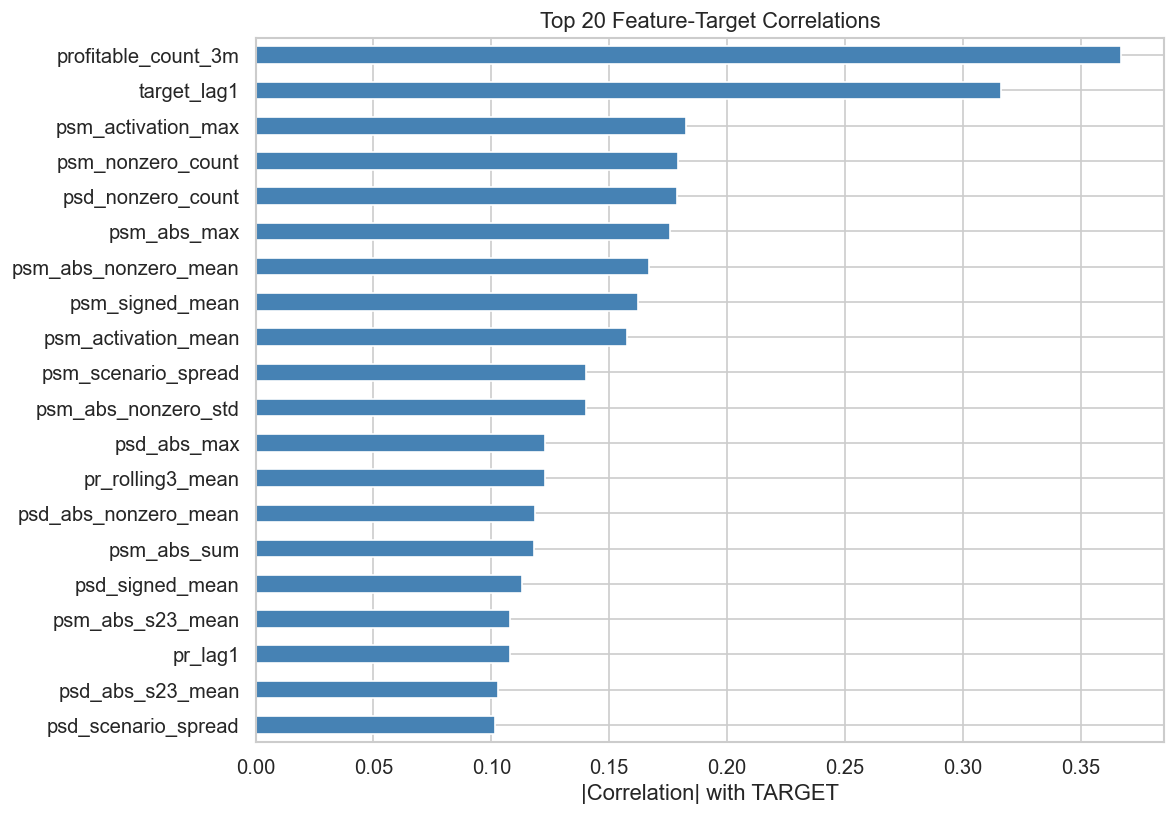

In [15]:
# --- Feature-target correlations ---
skip_cols = {'EID', 'MONTH', 'DECISION_MONTH', 'PEAKID', 'PR', 'C', 'PROFIT', 'TARGET', 'season'}
numeric_cols = [c for c in master_df.select_dtypes(include=[np.number]).columns
                if c not in skip_cols]

correlations = (
    master_df[numeric_cols + ['TARGET']]
    .corr()['TARGET']
    .drop('TARGET')
    .abs()
    .sort_values(ascending=False)
)

print("--- Top 20 features correlated with TARGET ---")
print(correlations.head(20).to_string())

# Plot
fig, ax = plt.subplots(figsize=(10, 7))
correlations.head(20).plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('|Correlation| with TARGET')
ax.set_title('Top 20 Feature-Target Correlations')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## Section 9 — Export Master Dataset

Export as Parquet. **No rows are dropped** — all ~500K opportunities are kept.

The dataset is ready for:
- Time-based train/val split: `MONTH < '2023'` for train, `MONTH >= '2023'` for validation
- Classification target: `TARGET` (binary)
- Economic evaluation: `PROFIT = |PR| - |C|`

Output: `master_dataset_final_ml.parquet`

In [ ]:
# --- Export ---
master_export = master_df.sort_values(['MONTH', 'EID', 'PEAKID']).copy()

output_path = 'data/master_dataset.parquet'
master_export.to_parquet(output_path, index=False)
print(f'Exported to: {output_path}')

feature_cols = [c for c in master_export.columns if c not in
                ['EID', 'MONTH', 'DECISION_MONTH', 'PEAKID',
                 'C', 'PR', 'PR_signed', 'PROFIT', 'TARGET', 'season']]

print(f"\n{'='*60}")
print(f'  MASTER DATASET — v3 (HYBRID UNIVERSE) SUMMARY')
print(f"{'='*60}")
print(f'  Rows:                  {len(master_export):,}')
print(f'  Feature columns:       {len(feature_cols)}')
print(f'  Unique EIDs:           {master_export["EID"].nunique():,}')
print(f'  Month range:           {master_export["MONTH"].min()} -> {master_export["MONTH"].max()}')
print(f'  Profitable (=1):       {master_export["TARGET"].sum():,} ({master_export["TARGET"].mean()*100:.2f}%)')
print(f'  Market-validated rows: {(master_export["is_sim_only"]==0).sum():,}')
print(f'  Sim-only rows:         {(master_export["is_sim_only"]==1).sum():,}')
print(f'  Universe:              HYBRID — market-validated UNION strong-sim')
print(f'  Sim thresholds:        p{SIM_ACTIVATION_PCT} ACTIVATIONLEVEL={ACT_THRESH:.4f}, p{SIM_PSM_PCT} |PSM|={PSM_THRESH:.4f}')
print(f'  Profit formula:        |PR| - |C|  (confirmed by MAG)')
print(f'  Anti-leakage:          sim_daily DAY 1-7 only')
print(f'  Lag leakage fix:       PR/PROFIT lags shift +2 (nearest full month = M-1)')
print(f'  Partial-month PR:      pr_partial_current (days 1-7 of M)')
print(f'  has_history flags:     3 binary flags pre-NaN-fill')
print(f'  is_sim_only flag:      1 = no market history, 0 = market-validated')
print(f'  Enriched impacts:      HYDRO/WIND/LOAD log_abs_mean + abs_max')

print(f'\n  Feature list:')
for col in feature_cols:
    print(f'    - {col}')

con.close()
print('\nDone.')

## Appendix — Quick-Start Modeling Template

```python
import pandas as pd
from lightgbm import LGBMClassifier, LGBMRegressor
from sklearn.metrics import f1_score, classification_report

master = pd.read_parquet('data/master_dataset.parquet')

feature_cols = [c for c in master.columns if c not in
                ['EID', 'MONTH', 'DECISION_MONTH', 'PEAKID',
                 'C', 'PR', 'PR_signed', 'PROFIT', 'TARGET', 'season']]

# Time-based split — NO random shuffling!
train = master[master['MONTH'] < '2023']
val   = master[master['MONTH'] >= '2023']

X_train, y_train = train[feature_cols], train['TARGET']
X_val,   y_val   = val[feature_cols],   val['TARGET']

# --- Two-stage strategy ---
# Stage 1: Classifier (optimizes F1)
clf = LGBMClassifier(n_estimators=300, max_depth=6,
                     class_weight='balanced', random_state=42)
clf.fit(X_train, y_train)
proba = clf.predict_proba(X_val)[:, 1]

# Stage 2: Regressor (optimizes net profit)
reg = LGBMRegressor(n_estimators=300, max_depth=6, random_state=42)
reg.fit(X_train, train['PROFIT'])
pred_profit = reg.predict(X_val)

# Selection: confident AND high-profit, K ∈ [10, 100]
val_copy = val.copy()
val_copy['proba'] = proba
val_copy['pred_profit'] = pred_profit
candidates = val_copy[val_copy['proba'] > 0.5]
selected = candidates.nlargest(min(100, max(10, len(candidates))), 'pred_profit')

print(f"F1 (all):   {f1_score(y_val, (proba > 0.5).astype(int)):.3f}")
print(f"Selected:   {len(selected)} opportunities")
print(f"Net profit: {selected['PROFIT'].sum():,.2f}")
```